# Projeto: Avaliação de Risco de Crédito (German Credit Data)
## Metodologia: CRISP-ML(Q)

### 1. Business and Data Understanding.  
**Objetivo de Negócio:** O objetivo principal é desenvolver um modelo preditivo capaz de classificar solicitantes de crédito em dois grupos: Bom Pagador ou Mau Pagador. No contexto bancário, o custo de conceder crédito a um cliente inadimplente (Falso Negativo) é significativamente maior do que o custo de recusar um bom cliente (Falso Positivo).

Qualidade e Requisitos (ML(Q)):
> https://ml-ops.org/content/crisp-ml

- Acurácia Mínima: Definir um threshold aceitável para a operação.

- Interpretabilidade: Dado que se trata de crédito bancário, o modelo deve permitir explicar o porquê de uma negação (compliance).

- Robustez: O modelo deve lidar bem com variações demográficas presentes na base.

**Descrição dos Dados:** A base Statlog German Credit Data contém 1.000 instâncias com 20 atributos que descrevem a situação financeira e o perfil dos clientes (ex: status da conta corrente, duração do empréstimo, histórico de crédito, propósito, etc.).

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

pd.set_option('display.max_columns', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/german-credit-data/german_credit_data.csv


In [2]:
df = pd.read_csv('/kaggle/input/german-credit-data/german_credit_data.csv')
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


In [3]:
rename_map = {
    'laufkont': 'status_conta_corrente',
    'laufzeit': 'duracao_meses',
    'moral': 'historico_credito',
    'verw': 'finalidade_credito',
    'hoehe': 'valor_credito',
    'sparkont': 'conta_poupanca',
    'beszeit': 'tempo_emprego_atual',
    'rate': 'taxa_prestacao_renda',
    'famges': 'estado_civil_sexo',
    'buerge': 'fiador',
    'wohnzeit': 'tempo_residencia',
    'verm': 'propriedade',
    'alter': 'idade',
    'weitkred': 'outros_planos_parcelamento',
    'wohn': 'tipo_moradia',
    'bishkred': 'creditos_existentes_banco',
    'beruf': 'profissao',
    'pers': 'dependentes',
    'telef': 'telefone',
    'gastarb': 'trabalhador_estrangeiro',
    'kredit': 'target'
}
df.rename(columns=rename_map, inplace=True)


#### 1.1 Data Dictionary

|   |   |   |
|---|---|---|
|**Nome**|**Tipo**|**Descrição**|
|status_conta_corrente|Categórico (Ordinal)|Situação da conta corrente existente|
|duracao_meses|Numérico|Duração|
|historico_credito|Categórico (Nominal)|Histórico de crédito|
|finalidade_credito|Categórico (Nominal)|Finalidade|
|valor_credito|Numérico|Valor do crédito|
|conta_poupanca|Categórico (Ordinal)|Conta poupança / títulos|
|tempo_emprego_atual|Categórico (Ordinal)|Emprego atual desde|
|taxa_prestacao_renda|Categórico (Ordinal)|Taxa de prestação como porcentagem da renda disponível|
|estado_civil_sexo|Categórico (Nominal)|Situação pessoal e sexo|
|fiador|Categórico (Nominal)|Outros devedores / fiadores|
|tempo_residencia|Categórico (Ordinal)|Residência atual desde|
|propriedade|Categórico (Nominal)|Propriedade|
|idade|Numérico|Idade|
|outros_planos_parcelamento|Categórico (Nominal)|Outros planos de parcelamento|
|tipo_moradia|Categórico (Nominal)|Moradia|
|creditos_existentes_banco|Categórico (Ordinal)|Número de créditos existentes neste banco|
|profissao|Categórico (Nominal)|Profissão|
|dependentes|Categórico (Ordinal)|Número de pessoas pelas quais o indivíduo é responsável financeiramente|
|telefone|Categórico (Nominal)|Telefone|
|trabalhador_estrangeiro|Categórico (Nominal)|Trabalhador estrangeiro|
|target|Binary Target Variable|0 = Bom, 1 = Ruim|

### 2. Data Engineering (Data Preparation)  
Nesta fase, realizamos a seleção, limpeza e padronização dos dados. O foco principal do ML(Q) aqui é a mitigação de riscos através de testes de qualidade e a criação de um pipeline de transformação reprodutível.

#### 2.1 Data Cleaning & Quality Assurance (Provando a ausência de nulos)  
Embora a documentação indique que não há valores ausentes, o processo de qualidade exige a verificação programática para evitar a propagação de erros.


In [4]:
# Verificação de valores ausentes (Data Quality Requirement)
null_counts = df.isnull().sum()
print("Contagem de valores nulos por coluna:")
print(null_counts[null_counts > 0] if any(null_counts > 0) else "Nenhum valor nulo encontrado.")

# Verificação de tipos de dados para garantir a padronização
print("\nTipos de dados detectados:")
print(df.dtypes)

Contagem de valores nulos por coluna:
Nenhum valor nulo encontrado.

Tipos de dados detectados:
status_conta_corrente         int64
duracao_meses                 int64
historico_credito             int64
finalidade_credito            int64
valor_credito                 int64
conta_poupanca                int64
tempo_emprego_atual           int64
taxa_prestacao_renda          int64
estado_civil_sexo             int64
fiador                        int64
tempo_residencia              int64
propriedade                   int64
idade                         int64
outros_planos_parcelamento    int64
tipo_moradia                  int64
creditos_existentes_banco     int64
profissao                     int64
dependentes                   int64
telefone                      int64
trabalhador_estrangeiro       int64
target                        int64
dtype: object


#### 2.2 Data Cleaning & Transformation (Rótulos Legíveis)  
Para garantir que a análise seja auditável por humanos e útil para o negócio, aplicamos um mapeamento de códigos numéricos/categóricos para descrições semânticas em português.

> Nota de Qualidade: O uso do .fillna(df[col]) no loop de mapeamento garante que, caso surja um código novo (drift de dados), não perderemos a informação original, embora o ideal para o ML(Q) seja monitorar esses casos.

In [5]:
# Transforma os códigos categóricos do German Credit em rótulos legíveis em português,
# facilitando o EDA e a interpretação do modelo de risco.


mappings = {
    "status_conta_corrente": {
        1: "sem conta corrente",
        2: "< 0 DM",
        3: "0 <= ... < 200 DM",
        4: ">= 200 DM / cessão de salário"
    },
    "historico_credito": {
        0: "atraso em pagamentos no passado",
        1: "conta crítica/outros créditos existentes",
        2: "nenhum crédito/ todos pagos em dia",
        3: "créditos existentes pagos em dia até agora",
        4: "todos os créditos neste banco pagos em dia"
    },
    "finalidade_credito": {
        0: "outros",
        1: "carro (novo)",
        2: "carro (usado)",
        3: "móveis/equipamentos",
        4: "rádio/televisão",
        5: "eletrodomésticos",
        6: "reparos",
        7: "educação",
        8: "ferias",
        9: "treinamentos",
        10: "negócios"        
    },
    "conta_poupanca": {
        1: "desconhecido/sem poupança",
        2: "< 100 DM",
        3: "100 <= ... < 500 DM",
        4: "500 <= ... < 1000 DM",
        5: ">= 1000 DM"
    },
    "tempo_emprego_atual": {
        1: "desempregado",
        2: "< 1 ano",
        3: "1 <= ... < 4 anos",
        4: "4 <= ... < 7 anos",
        5: ">= 7 anos"
    },
    "estado_civil_sexo": {
        1: "homem: divorciado/separado",
        2: "mulher: divorciada/separada/casada ou homem: solteiro",
        3: "homem: casado/viúvo",
        4: "mulher: solteira"
    },
    "fiador": {
        1: "nenhum",
        2: "co-proponente",
        3: "fiador"
    },
    "tempo_residencia": {
        1: "< 1 ano",
        2: "1 <= … < 4 anos",
        3: "4 <= … < 7 anos",
        4: ">= 7 anos"
    },
    "propriedade": {
        4: "imóvel",
        3: "poupança habitacional/seguro de vida",
        2: "carro ou outros bens",
        1: "desconhecido/sem propriedade"
    },
    "outros_planos_parcelamento": {
        1: "banco",
        2: "lojas",
        3: "nenhum"
    },
    "tipo_moradia": {
        1: "sem custo",
        2: "aluguel",
        3: "própria"        
    },
    "profissao": {
        1: "desempregado/não qualificado não-residente",
        2: "não qualificado residente",
        3: "empregado qualificado",
        4: "gerência/alta qualificação"
    },
    "telefone": {
        1: "não",
        2: "sim"
    },
    "trabalhador_estrangeiro": {
        1: "sim",
        2: "não"
    }
}

In [6]:
# Aplicação dos mapeamentos para legibilidade (Conforme código definido)
for col, mapping in mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).fillna(df[col])

# Verificação do Target 
print("Distribuição do Target (0=Bom, 1=Ruim):")
print(df['target'].value_counts())

Distribuição do Target (0=Bom, 1=Ruim):
target
1    700
0    300
Name: count, dtype: int64


#### 2.3 Feature Engineering (Data Selection & Unit Testing)  
Agora que os dados estão legíveis, precisamos realizar dois testes críticos de engenharia antes de prosseguir:

* Unit Test para Nulos: Provar sistematicamente que não há dados faltantes.

* Verificação de Tipos Post-Mapping: Garantir que as colunas mapeadas agora são tratadas como object ou category pelo Pandas, para que o modelo não tente tratá-las como números contínuos erroneamente.

In [7]:
# Teste de Unidade: Garantia de Ausência de Nulos
def test_no_nulls(data):
    assert data.isnull().sum().sum() == 0, "Erro: Foram encontrados valores nulos!"
    return "Teste de Nulos: PASSED"

print(test_no_nulls(df))

# Visualização das primeiras linhas para confirmar a tradução
df.head()

Teste de Nulos: PASSED


,status_conta_corrente,duracao_meses,historico_credito,finalidade_credito,valor_credito,conta_poupanca,tempo_emprego_atual,taxa_prestacao_renda,estado_civil_sexo,fiador,tempo_residencia,propriedade,idade,outros_planos_parcelamento,tipo_moradia,creditos_existentes_banco,profissao,dependentes,telefone,trabalhador_estrangeiro,target
0,sem conta corrente,18,todos os créditos neste banco pagos em dia,carro (usado),1049,desconhecido/sem poupança,< 1 ano,4,mulher: divorciada/separada/casada ou homem: s...,nenhum,>= 7 anos,carro ou outros bens,21,nenhum,sem custo,1,empregado qualificado,2,não,não,1
1,sem conta corrente,9,todos os créditos neste banco pagos em dia,outros,2799,desconhecido/sem poupança,1 <= ... < 4 anos,2,homem: casado/viúvo,nenhum,1 <= … < 4 anos,desconhecido/sem propriedade,36,nenhum,sem custo,2,empregado qualificado,1,não,não,1
2,< 0 DM,12,nenhum crédito/ todos pagos em dia,treinamentos,841,< 100 DM,4 <= ... < 7 anos,2,mulher: divorciada/separada/casada ou homem: s...,nenhum,>= 7 anos,desconhecido/sem propriedade,23,nenhum,sem custo,1,não qualificado residente,2,não,não,1
3,sem conta corrente,12,todos os créditos neste banco pagos em dia,outros,2122,desconhecido/sem poupança,1 <= ... < 4 anos,3,homem: casado/viúvo,nenhum,1 <= … < 4 anos,desconhecido/sem propriedade,39,nenhum,sem custo,2,não qualificado residente,1,não,sim,1
4,sem conta corrente,12,todos os créditos neste banco pagos em dia,outros,2171,desconhecido/sem poupança,1 <= ... < 4 anos,4,homem: casado/viúvo,nenhum,>= 7 anos,carro ou outros bens,38,banco,aluguel,2,não qualificado residente,2,não,sim,1


### 3. ML Model Engineering (Modelagem)  
Agora entramos na terceira fase do CRISP-ML(Q). De acordo com a metodologia, esta fase foca na seleção de algoritmos, treinamento e ajuste de hiperparâmetros. No entanto, antes de treinar, precisamos preparar os dados para o computador (Machine Learning), já que os transformamos em rótulos legíveis para humanos.

Tópicos para esta fase:
* Codificação de Variáveis (Encoding): Como agora temos strings (ex: "carro novo", "aluguel"), precisamos converter esses dados de volta para um formato que os modelos de ML entendam (One-Hot Encoding para nominais e Ordinal Encoding para ordinais).

* Divisão de Dados (Train/Test Split): Separar uma parcela dos dados para que possamos testar a performance de forma justa.

* Tratamento de Desbalanceamento: Notei pela sua imagem que temos 700 (Bom) e 300 (Ruim). Isso é um desbalanceamento moderado que pode enviesar o modelo para o "Bom pagador".

* Seleção de Algoritmos: Escolha de modelos (ex: Random Forest, XGBoost ou Regressão Logística).

#### 3.1 Encoding e Divisão dos Dados (Split)  
Nesta etapa, vamos separar as variáveis explicativas **`X`** do alvo **`y`** e dividir o conjunto em treino e teste.   
Logo após, definiremos a estrutura do pipeline de pré-processamento.
- Passo A: Separação e SplitUtilizaremos uma divisão clássica (ex: 80/20) e manteremos a estratificação, dado o desbalanceamento de classes (700/300) que observamos anteriormente.

In [8]:
from sklearn.model_selection import train_test_split

# Separação de features e target
X = df.drop(columns=['target'])
y = df['target']

# Divisão Treino/Teste com estratificação para manter a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 800 amostras
Teste: 200 amostras


* Passo B: Estrutura do Pipeline de Engenharia
  
Aqui, definimos como cada tipo de coluna será "codificado" para o modelo:

- Numéricas: `StandardScaler` (Padronização para mitigar viés de escala).

- Ordinais: `OrdinalEncoder` (Preserva a hierarquia, ex: < 0 DM < 200 DM).

- Nominais: `OneHotEncoder` (Cria colunas binárias para categorias sem ordem).

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Definição dos grupos de colunas com base no nosso dicionário
colunas_numericas = ['duracao_meses', 'valor_credito', 'idade']

colunas_ordinais = [
    'status_conta_corrente', 'conta_poupanca', 'tempo_emprego_atual', 
    'taxa_prestacao_renda', 'tempo_residencia', 'creditos_existentes_banco', 
    'dependentes'
]

colunas_nominais = [
    'historico_credito', 'finalidade_credito', 'estado_civil_sexo', 
    'fiador', 'propriedade', 'outros_planos_parcelamento', 
    'tipo_moradia', 'profissao', 'telefone', 'trabalhador_estrangeiro'
]

# Criação do Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('ord', OrdinalEncoder(), colunas_ordinais),
        ('nom', OneHotEncoder(handle_unknown='ignore'), colunas_nominais)
    ]
)

print("Pré-processador configurado com sucesso.")

Pré-processador configurado com sucesso.


#### 3.3 Definição do Modelo e Pipeline Final  
No CRISP-ML(Q), a fase de modelagem deve garantir que o treinamento seja reprodutível.  
Vamos encapsular o pré-processador que criamos e o classificador em um único objeto Pipeline.

> **Nota de Qualidade (MLQ):** Utilizamos o parâmetro class_weight='balanced'. Isso é crucial porque, como vimos na sua análise, temos um desbalanceamento (700 bons vs. 300 ruins).  
> Este ajuste penaliza mais o erro na classe minoritária (os maus pagadores), alinhando o modelo ao objetivo de negócio de mitigar inadimplência.

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Criando o Pipeline completo: Pré-processamento + Modelo
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, 
                                           random_state=42, 
                                           class_weight='balanced')) # Ajuste para o desequilíbrio (700/300)
])

# Treinamento do Modelo
pipeline_rf.fit(X_train, y_train)

print("Pipeline de Random Forest treinado com sucesso.")

Pipeline de Random Forest treinado com sucesso.


### 4. Model Evaluation  

Agora que o modelo está treinado, precisamos entrar na fase de Avaliação.  
Para um cientista de dados com sua experiência em Engenharia de Software e IA, sabemos que apenas a "Acurácia" não basta. 

    Precisamos olhar para:

    * Matriz de Confusão: Para ver quantos "Maus" estamos deixando passar.
    
    * Relatório de Classificação: Precision, Recall e F1-Score.
    
    * Curva ROC e AUC: Para medir a capacidade de separação entre as classes.

#### 4.1 Métricas de Performance e Matriz de Confusão  

Vamos gerar a matriz e o relatório de classificação:

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.33      0.47        60
           1       0.77      0.96      0.85       140

    accuracy                           0.77       200
   macro avg       0.77      0.65      0.66       200
weighted avg       0.77      0.77      0.74       200



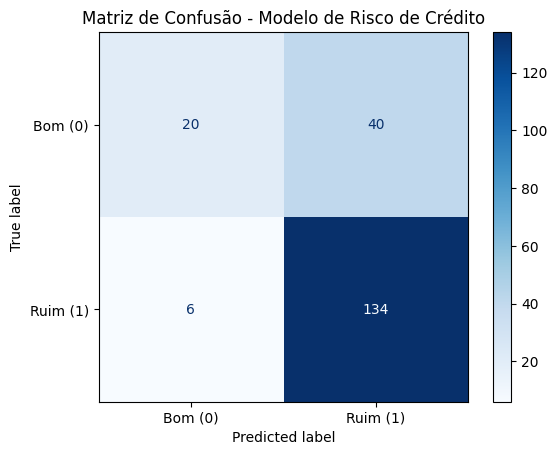

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predições no conjunto de teste
y_pred = pipeline_rf.predict(X_test)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bom (0)', 'Ruim (1)'])

# Relatório de Classificação
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# Plot da Matriz
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Modelo de Risco de Crédito')
plt.show()

### 4.2 Análise do Resultado (Perspectiva de Negócio)  
Ao analisar a Matriz de Confusão, precisamos observar:

 * Falsos Negativos: Clientes que o modelo disse ser "Bom" (0), mas que eram "Ruim" (1). Este é o erro mais caro para o banco.

 * Falsos Positivos: Clientes que o modelo classificou como "Ruim" (1), mas eram "Bom" (0). Isso representa custo de oportunidade (perda de bons clientes).

#### 4.3 Curva ROC-AUC  
A Curva ROC nos dirá quão bem o modelo consegue separar as duas classes em diferentes limiares de decisão.

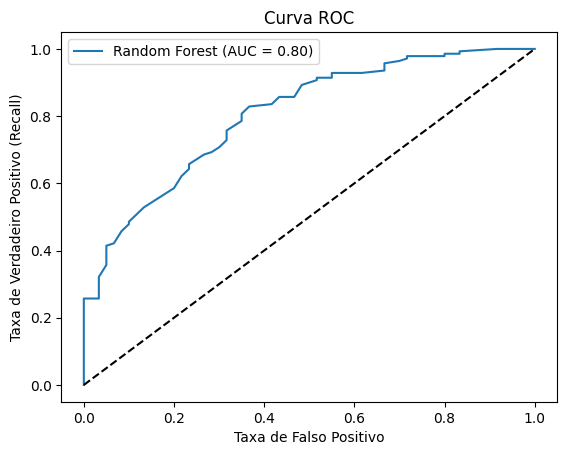

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = pipeline_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

#### 4.4 Resumo da Avaliação Técnica  
Abaixo, os pontos principais baseados nos seus outputs:

 * Poder de Separação (AUC = 0.80): O modelo possui uma boa capacidade discriminatória. Um AUC de 0.80 indica que há 80% de chance de o modelo classificar um "Mau Pagador" aleatório acima de um "Bom Pagador" aleatório.

* Recall Elevado para Risco (0.96 para Classe 1): O modelo identificou corretamente 96% dos inadimplentes reais (apenas 6 "Maus" passaram como "Bons"). Isso é excelente para mitigar perdas financeiras.

* Custo de Oportunidade (Precision Classe 1 / Recall Classe 0): O modelo está classificando muitos "Bons" como "Ruins" (40 casos na matriz de confusão). Isso resulta em um recall baixo para a classe 0 (0.33), indicando que o banco estaria negando crédito para bons pagadores para garantir segurança.

    - Diagnóstico para Negócio
        O modelo está priorizando a segurança (evitar inadimplentes) em detrimento do volume (aprovar mais clientes). No jargão bancário, temos um modelo com baixo appetite ao risco.

>Nota de Qualidade (MLQ): O desbalanceamento e o class_weight='balanced' forçaram o modelo a focar na classe 1.
>Se o objetivo for aumentar a aprovação, precisaríamos ajustar o limiar (threshold) de decisão.

### 5. Model Deployment (Implantação)  
Esta fase foca em como o modelo sairá do ambiente de desenvolvimento (Jupyter Notebook) para gerar valor real. 

- Estratégia de Deployment para o German Credit:
  
Exportação do Pipeline: Utilizaremos a biblioteca joblib ou pickle para salvar o objeto pipeline_rf completo (com pré-processador e modelo). Isso garante que os dados novos passem pelas mesmas transformações de treino.

- Arquitetura de Consumo:

    Batch (Lote): Processamento noturno de todas as propostas de crédito do dia.

    API (Real-time): Um serviço (Flask/FastAPI) que recebe os dados do cliente e retorna o score instantaneamente.

In [13]:
import joblib

# Definindo o nome do arquivo
file_name = 'pipeline_risco_credito_german.pkl'

# Salvando o pipeline completo (Preprocessador + Modelo)
# Isso garante que em produção você não precise repetir o código de tratamento
joblib.dump(pipeline_rf, file_name)

print(f"Pipeline salvo com sucesso em: {file_name}")

Pipeline salvo com sucesso em: pipeline_risco_credito_german.pkl


In [14]:
# Carregando o modelo
modelo_producao = joblib.load('pipeline_risco_credito_german.pkl')

# Exemplo de predição com dados novos (X_novo deve ser um DataFrame com as mesmas colunas)
# predicao = modelo_producao.predict(X_novo)

### 6. Model Monitoring and Maintenance (Monitoramento)  
O "Q" do CRISP-ML(Q) foca na Garantia de Qualidade Contínua. Um modelo de crédito pode degradar se o comportamento da população mudar (ex: uma crise econômica).

 - Plano de Manutenção:
    * Detecção de Drift: Monitorar se a distribuição da idade ou valor_credito dos novos proponentes está mudando em relação ao treino.

    * Performance Check: Comparar periodicamente o target real (se o cliente pagou ou não após alguns meses) com a predição feita pelo modelo.

    * Retreinamento: Definir um gatilho (ex: queda de 10% no AUC) para automatizar o retreino do pipeline.